# Hodgkin-Huxley Punctual Model

This notebook implements and tests the classic Hodgkin-Huxley (HH) model in Python, based on the original squid giant axon equations.


## 1. Model

The Hodgkin-Huxley model describes the dynamics of **sodium, potassium, and leakage currents** across the axon membrane:

$
C_m \frac{dV}{dt} = I_\text{inj} - (I_\text{Na} + I_\text{K} + I_\text{L})
$

where:  

- $V$ = membrane potential (mV)  
- $C_m$ = membrane capacitance (µF/cm²)  
- $I_\text{inj}$ = injected current (µA/cm²)  
- $I_\text{Na}, I_\text{K}, I_\text{L}$ = sodium, potassium, and leak currents (µA/cm²)


## 2. Ionic Currents

### Sodium Current

$
I_\text{Na} = g_\text{Na} \, m^3 h \, (V - E_\text{Na})
$

- $g_\text{Na}$ = maximal sodium conductance (S/cm²)  
- $m$ = activation gating variable  
- $h$ = inactivation gating variable  
- $E_\text{Na}$ = sodium reversal potential (mV)  

### Potassium Current

$
I_\text{K} = g_\text{K} \, n^4 \, (V - E_\text{K})
$

- $g_\text{K}$ = maximal potassium conductance (S/cm²)  
- $n$ = potassium activation gating variable  
- $E_\text{K}$ = potassium reversal potential (mV)  

### Leak Current

$
I_\text{L} = g_\text{L} \, (V - E_\text{L})
$

- $g_\text{L}$ = leak conductance (S/cm²)  
- $E_\text{L}$ = leak reversal potential (mV)


## 3. Gating Variable Dynamics

The gating variables $m, h, n$ follow first-order kinetics:

$$
\frac{dm}{dt} = \frac{m_\infty(V) - m}{\tau_m(V)}, \quad
\frac{dh}{dt} = \frac{h_\infty(V) - h}{\tau_h(V)}, \quad
\frac{dn}{dt} = \frac{n_\infty(V) - n}{\tau_n(V)}
$$

Where the steady-state values and time constants are:

$$
x_\infty(V) = \frac{\alpha_x(V)}{\alpha_x(V) + \beta_x(V)}, \quad
\tau_x(V) = \frac{1}{\alpha_x(V) + \beta_x(V)}, \quad x \in \{m,h,n\}
$$

The rate functions $\alpha$ and $\beta$ are voltage-dependent:

$$
\alpha_m(V) = 0.1 \, \frac{-(V+40)}{1 - \exp(-(V+40)/10)}, \quad
\beta_m(V) = 4 \exp(-(V+65)/18)
$$

$$
\alpha_h(V) = 0.07 \exp(-(V+65)/20), \quad
\beta_h(V) = \frac{1}{\exp(-(V+35)/10) + 1}
$$

$$
\alpha_n(V) = 0.01 \, \frac{-(V+55)}{1 - \exp(-(V+55)/10)}, \quad
\beta_n(V) = 0.125 \exp(-(V+65)/80)
$$


## 4. Units

The NEURON HH.mod file defines currents in **mA/cm²**.  
For consistency with µF/cm² for capacitance, it is convenient to convert:

$$
I_\text{ion} [\mu\text{A/cm²}] = I_\text{ion} [\text{mA/cm²}] \times 10^3
$$

## 5. Python implementation

### Required packages and helpers

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def vtrap(x, y):            #to avoid near zero division
    z = x / y
    small = np.abs(z) < 1e-6
    return np.where(small, y * (1 - z / 2), x / (np.exp(z) - 1))

### Model Parameters

source: [HH.mod](https://github.com/neuronsimulator/nrn/blob/master/src/nrnoc/hh.mod)

In [4]:
Cm = 1.0        # uF/cm^2
gnabar = 0.12   # S/cm^2
gkbar = 0.036   # S/cm^2
gl = 0.0003
el = -54.3
ena = 50.0
ek = -77.0
Vrest = -65.0
celsius = 6.3

### Simulation Parameters

In [5]:

dt = 0.01  # ms
tstop = 50.0  # ms
time = np.arange(0, tstop, dt)

### Current Injection: 10 ms pulse

In [6]:
I_inj = np.zeros_like(time)
I_inj[(time > 5) & (time < 15)] = 10.0  # uA/cm^2

### Gating variables rate equations

In [7]:
def rates(V):
    q10 = 3 ** ((celsius - 6.3) / 10.0)

    alpha_m = 0.1 * vtrap(-(V + 40), 10)
    beta_m = 4.0 * np.exp(-(V + 65) / 18)
    mtau = 1 / (q10 * (alpha_m + beta_m))
    minf = alpha_m / (alpha_m + beta_m)

    alpha_h = 0.07 * np.exp(-(V + 65) / 20)
    beta_h = 1 / (np.exp(-(V + 35) / 10) + 1)
    htau = 1 / (q10 * (alpha_h + beta_h))
    hinf = alpha_h / (alpha_h + beta_h)

    alpha_n = 0.01 * vtrap(-(V + 55), 10)
    beta_n = 0.125 * np.exp(-(V + 65) / 80)
    ntau = 1 / (q10 * (alpha_n + beta_n))
    ninf = alpha_n / (alpha_n + beta_n)

    return minf, mtau, hinf, htau, ninf, ntau

### Initialization

In [8]:
V = Vrest * np.ones_like(time) #Vm is initialized at Vrest
m = np.zeros_like(time)
h = np.zeros_like(time)
n = np.zeros_like(time)
ina = np.zeros_like(time)
ik = np.zeros_like(time)
il = np.zeros_like(time)

# ----- Initialize gates at Vrest -----
minf, mtau, hinf, htau, ninf, ntau = rates(Vrest)
m[0] = minf
h[0] = hinf
n[0] = ninf

### Time integration (CNEXP / exact Euler for gates)

In [9]:
for i in range(1, len(time)):
    # update gating variables
    minf, mtau, hinf, htau, ninf, ntau = rates(V[i-1])
    m[i] = minf - (minf - m[i-1]) * np.exp(-dt/mtau)
    h[i] = hinf - (hinf - h[i-1]) * np.exp(-dt/htau)
    n[i] = ninf - (ninf - n[i-1]) * np.exp(-dt/ntau)

    # compute currents (uA/cm^2)
    gna = gnabar * m[i]**3 * h[i]
    gk = gkbar * n[i]**4
    ina[i] = gna * (V[i-1] - ena)
    ik[i] = gk * (V[i-1] - ek)
    il[i] = gl * (V[i-1] - el)
    Iion = (ina[i] + ik[i] + il[i]) * 1e3  # convert mA/cm² -> µA/cm²

    # update voltage (Euler)
    V[i] = V[i-1] + dt * (I_inj[i-1] - Iion) / Cm

### Plot results

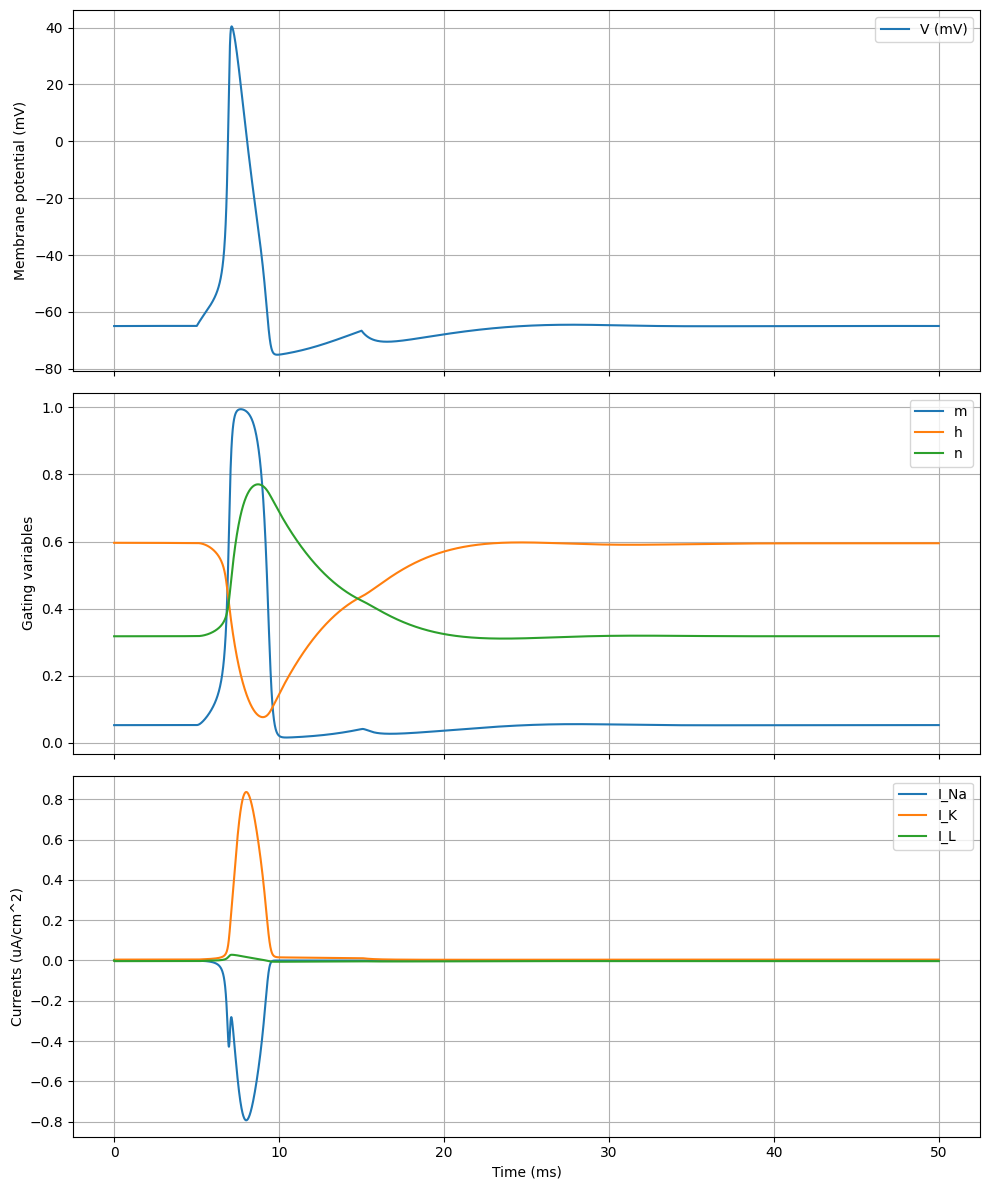

In [10]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Voltage
axs[0].plot(time, V, label='V (mV)')
axs[0].set_ylabel('Membrane potential (mV)')
axs[0].legend()
axs[0].grid(True)

# Gating variables
axs[1].plot(time, m, label='m')
axs[1].plot(time, h, label='h')
axs[1].plot(time, n, label='n')
axs[1].set_ylabel('Gating variables')
axs[1].legend()
axs[1].grid(True)

# Currents
axs[2].plot(time, ina, label='I_Na')
axs[2].plot(time, ik, label='I_K')
axs[2].plot(time, il, label='I_L')
axs[2].set_ylabel('Currents (uA/cm^2)')
axs[2].set_xlabel('Time (ms)')
axs[2].legend()
axs[2].grid(True)

fig.tight_layout()